In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings("ignore")

df = pd.read_csv("amazon_delivery.csv")

print("Row count:", len(df))
print("Columns:", df.columns.tolist())
df.head(3)

Row count: 43739
Columns: ['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports


In [5]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Fix missing values (order matters)
df['Agent_Rating'] = df['Agent_Rating'].fillna(df['Agent_Rating'].mean())
df['Weather'] = df['Weather'].fillna('Unknown')

# Parse dates and times
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Order_Time_parsed'] = pd.to_datetime('2000-01-01 ' + df['Order_Time'].astype(str), errors='coerce')
df = df.dropna(subset=['Order_Date', 'Order_Time_parsed'])

# Extract useful time features
df['Order_Hour'] = df['Order_Time_parsed'].dt.hour
df['Day_of_Week'] = df['Order_Date'].dt.day_name()
df['Is_Weekend'] = df['Order_Date'].dt.dayofweek >= 5

# Delivery_Time is in minutes (not hours)
df['Delivery_Minutes'] = df['Delivery_Time']

# Define "Late" = above average delivery time
avg_time = df['Delivery_Minutes'].mean()
df['Is_Late'] = (df['Delivery_Minutes'] > avg_time).astype(int)

print(f"\nAverage delivery time: {avg_time:.1f} minutes")
print(f"Late order rate: {df['Is_Late'].mean()*100:.1f}%")
print(f"Remaining rows: {len(df)}")

Missing values:
Order_ID             0
Agent_Age            0
Agent_Rating         0
Store_Latitude       0
Store_Longitude      0
Drop_Latitude        0
Drop_Longitude       0
Order_Date           0
Order_Time           0
Pickup_Time          0
Weather              0
Traffic              0
Vehicle              0
Area                 0
Delivery_Time        0
Category             0
Order_Time_parsed    0
Order_Hour           0
Day_of_Week          0
Is_Weekend           0
Delivery_Minutes     0
Is_Late              0
dtype: int64

Average delivery time: 124.9 minutes
Late order rate: 51.2%
Remaining rows: 43648


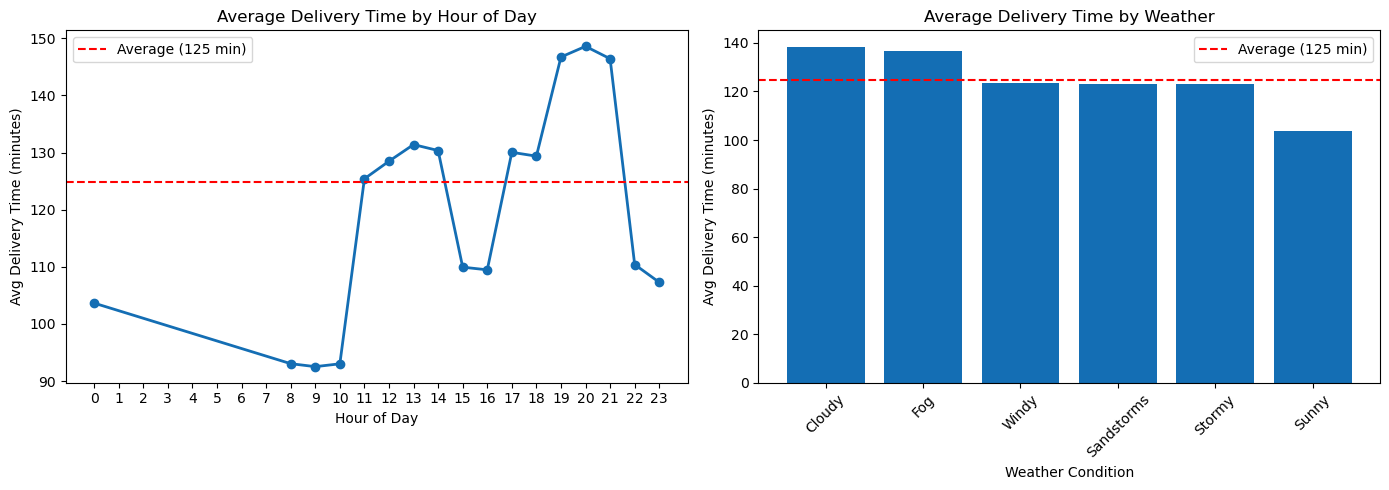

Delivery time by weather (minutes):
Weather
Cloudy        138.3
Fog           136.6
Windy         123.7
Sandstorms    123.2
Stormy        123.2
Sunny         103.7
Name: Delivery_Minutes, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Average delivery time by hour of day ---
hourly = df.groupby('Order_Hour')['Delivery_Minutes'].mean()

axes[0].plot(hourly.index, hourly.values, marker='o', color='#146EB4', linewidth=2)
axes[0].axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
axes[0].set_title('Average Delivery Time by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Delivery Time (minutes)')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# --- Plot 2: Average delivery time by weather ---
weather_avg = df.groupby('Weather')['Delivery_Minutes'].mean().sort_values(ascending=False)

axes[1].bar(weather_avg.index, weather_avg.values, color='#146EB4')
axes[1].axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
axes[1].set_title('Average Delivery Time by Weather')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Avg Delivery Time (minutes)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print exact numbers
print("Delivery time by weather (minutes):")
print(weather_avg.round(1))

Hour of Day findings:
8am-10am is the fastest delivery window (about 93 minutes)early morning orders
19pm-21pm is the slowest (about 147 minutes), nearly 60% longer than morning
There's a clear afternoon dip around 14-15pm which is interesting

Weather findings:
Cloudy and Fog add the most delay (about 138 minutes, +10% above average)
Sunny is the fastest (about 104 minutes, -17% below average)
Stormy surprisingly isn't the worst — worth noting in your analysis

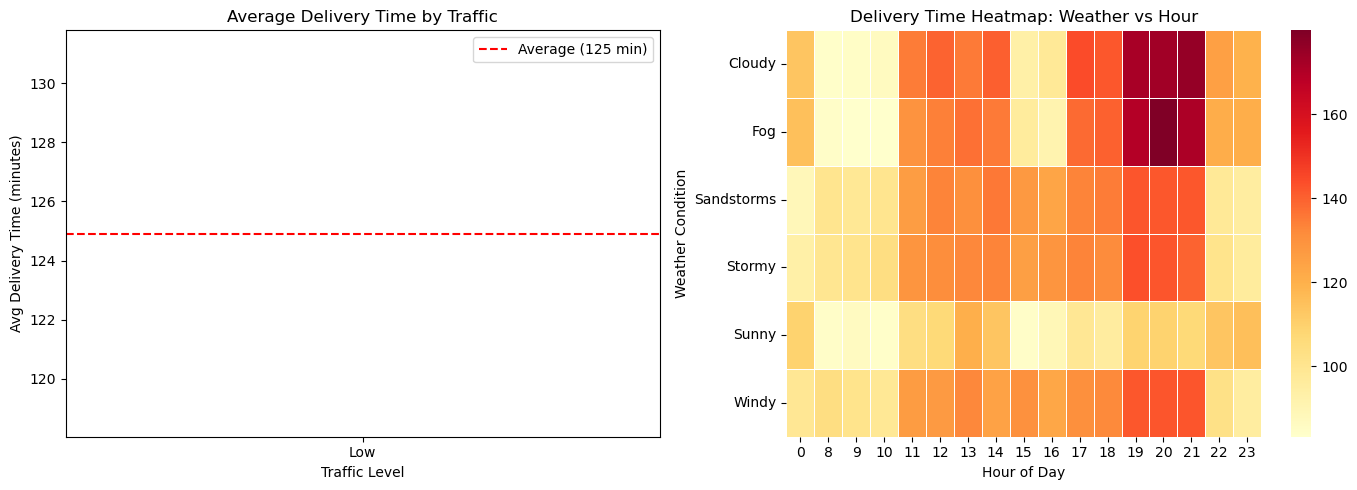

Delivery time by traffic (minutes):
Traffic
Low      NaN
Medium   NaN
High     NaN
Jam      NaN
Name: Delivery_Minutes, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Delivery time by traffic ---
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_avg = df.groupby('Traffic')['Delivery_Minutes'].mean().reindex(traffic_order)

axes[0].bar(traffic_avg.index, traffic_avg.values, color='#146EB4')
axes[0].axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
axes[0].set_title('Average Delivery Time by Traffic')
axes[0].set_xlabel('Traffic Level')
axes[0].set_ylabel('Avg Delivery Time (minutes)')
axes[0].legend()

# --- Plot 2: Heatmap — Hour vs Weather ---
heatmap_data = df.pivot_table(
    values='Delivery_Minutes',
    index='Weather',
    columns='Order_Hour',
    aggfunc='mean'
)

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[1], 
            linewidths=0.5, annot=False)
axes[1].set_title('Delivery Time Heatmap: Weather vs Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Weather Condition')

plt.tight_layout()
plt.show()

print("Delivery time by traffic (minutes):")
print(traffic_avg.round(1))

In [11]:
print(df['Traffic'].unique())
print(df['Traffic'].value_counts())

['High' 'Jam' 'Low' 'Medium']
Traffic
Low       14999
Jam       13725
Medium    10628
High       4296
Name: count, dtype: int64


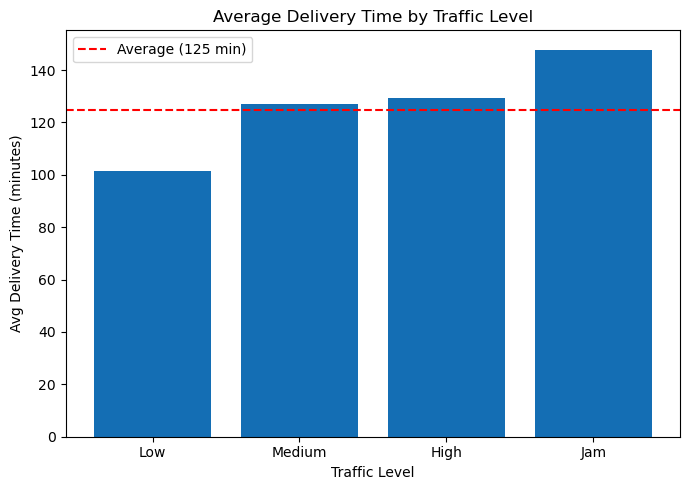

Delivery time by traffic (minutes):
Traffic
Low       101.4
Medium    126.8
High      129.4
Jam       147.8
Name: Delivery_Minutes, dtype: float64


In [9]:
# Fix trailing spaces in Traffic column
df['Traffic'] = df['Traffic'].str.strip()

# Replot traffic chart
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_avg = df.groupby('Traffic')['Delivery_Minutes'].mean().reindex(traffic_order)

plt.figure(figsize=(7, 5))
plt.bar(traffic_avg.index, traffic_avg.values, color='#146EB4')
plt.axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
plt.title('Average Delivery Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Avg Delivery Time (minutes)')
plt.legend()
plt.tight_layout()
plt.show()

print("Delivery time by traffic (minutes):")
print(traffic_avg.round(1))

Low traffic is 101 min, Jam is 148 min, nearly 50% longer.

Hour: Fastest: 8-10am (93 min); Slowest: 7-9pm (147 min);
Weather: Fastest: Sunny (104 min); Slowest: Cloudy (138 min);
Traffic: Fastest: Low (101 min); Slowest: Jam (148 min).

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Encode categorical variables
features = df[['Order_Hour', 'Weather', 'Traffic', 'Area', 'Is_Weekend']].copy()
features = pd.get_dummies(features, columns=['Weather', 'Traffic', 'Area'])

target = df['Is_Late']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features:", len(features.columns))

Training rows: 34918
Test rows: 8730
Features: 16


Model Accuracy: 72.0%

Detailed Report:
              precision    recall  f1-score   support

     On Time       0.72      0.69      0.71      4248
        Late       0.72      0.74      0.73      4482

    accuracy                           0.72      8730
   macro avg       0.72      0.72      0.72      8730
weighted avg       0.72      0.72      0.72      8730



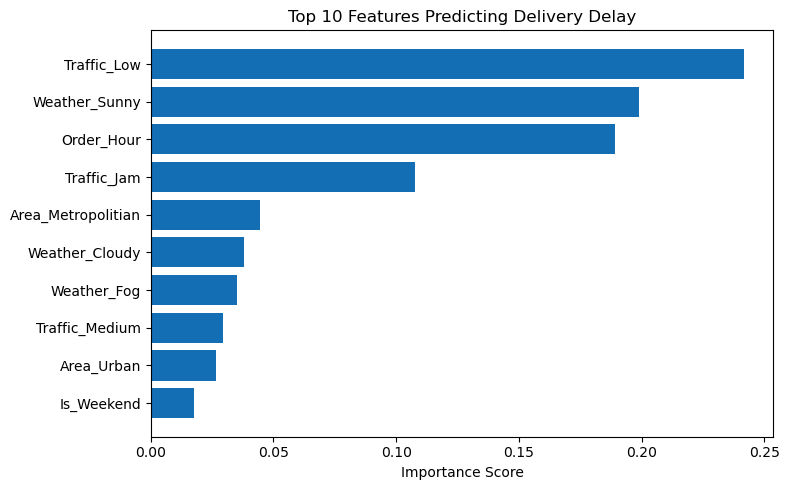


Top 10 most important features:
           Feature  Importance
       Traffic_Low    0.241509
     Weather_Sunny    0.198744
        Order_Hour    0.189291
       Traffic_Jam    0.107705
Area_Metropolitian    0.044601
    Weather_Cloudy    0.037991
       Weather_Fog    0.035001
    Traffic_Medium    0.029504
        Area_Urban    0.026585
        Is_Weekend    0.017651


In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

# Feature importance
importance_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#146EB4')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Predicting Delivery Delay')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importance_df.to_string(index=False))

The top 3 features driving delivery delay predictions are Traffic_Low (0.24), Weather_Sunny (0.20), and Order_Hour (0.19) — these three alone account for over 60% of the model's predictive power. Everything else is secondary.

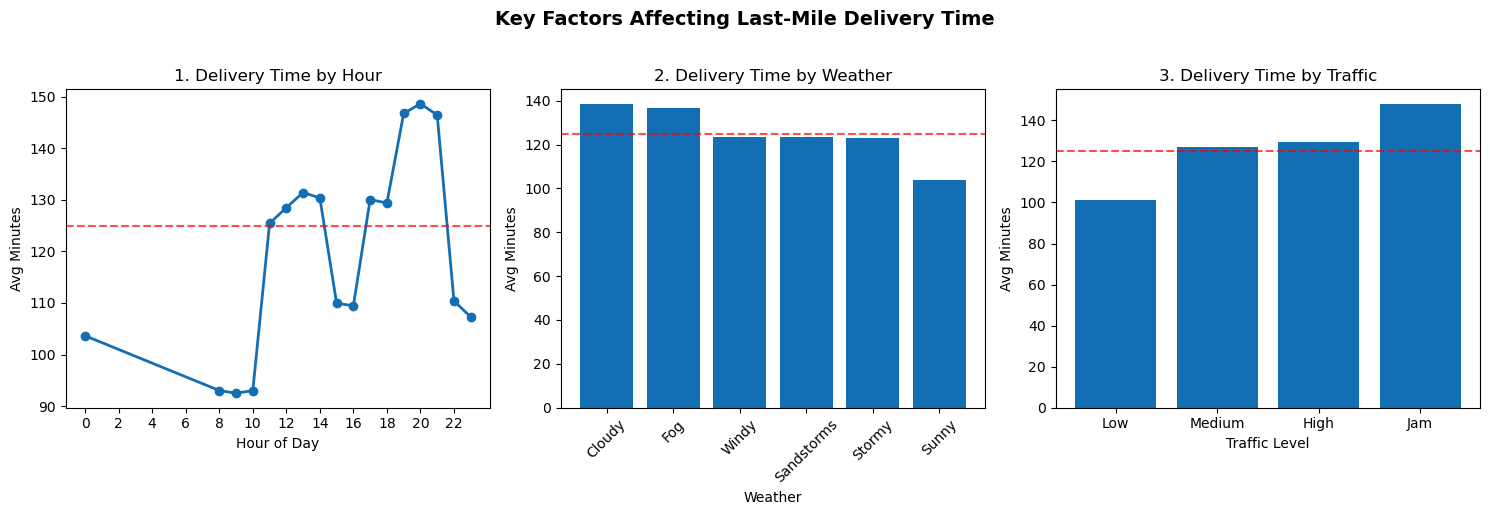

Chart saved as summary_findings.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Finding 1: Hour
hourly = df.groupby('Order_Hour')['Delivery_Minutes'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='#146EB4', linewidth=2)
axes[0].axhline(avg_time, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('1. Delivery Time by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Minutes')
axes[0].set_xticks(range(0, 24, 2))

# Finding 2: Weather
weather_avg = df.groupby('Weather')['Delivery_Minutes'].mean().sort_values(ascending=False)
axes[1].bar(weather_avg.index, weather_avg.values, color='#146EB4')
axes[1].axhline(avg_time, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('2. Delivery Time by Weather')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Avg Minutes')
axes[1].tick_params(axis='x', rotation=45)

# Finding 3: Traffic
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_avg = df.groupby('Traffic')['Delivery_Minutes'].mean().reindex(traffic_order)
axes[2].bar(traffic_avg.index, traffic_avg.values, color='#146EB4')
axes[2].axhline(avg_time, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('3. Delivery Time by Traffic')
axes[2].set_xlabel('Traffic Level')
axes[2].set_ylabel('Avg Minutes')

plt.suptitle('Key Factors Affecting Last-Mile Delivery Time', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('summary_findings.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as summary_findings.png")